แทนค่า missng

In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [2]:
# โหลดไฟล์ Excel (sheet2)
df = pd.read_excel("/content/new data.xlsx", sheet_name="Sheet2")

In [3]:
df

,Date,Showalter,Lifted,SWEAT,K,Cross,Vertical,TT Totals,CAPE,CIN,BRN,LCL Temp,LCL P,LCL P.1,MML θ,MML q,Thickness,PWAT,dBZ
0,2018-02-01,13.29,16.28,244.92,-27.1,5.7,19.7,25.4,0,0,0,276.14,783.2,314.16,296.13,6.16,5749,12.64,0.0
1,2018-02-02,10.78,11.77,127.18,-22.1,10.3,19.3,29.6,0,0,0,281.45,839.9,319.96,295.87,8.3,5746,16.33,0.0
2,2018-02-03,3.53,4.54,362.3,-14.3,19.3,19.7,39,15.68,-46.73,0.86,288.03,903.9,331.01,296.49,11.91,5729,25.68,0.0
3,2018-02-04,4.66,5.24,200.4,-18,18.8,19.3,38.1,0,-50.25,0,285.99,879.04,327.88,296.74,10.71,5734,22.45,0.0
4,2018-02-05,7.09,8.06,170.99,-0.7,15.3,18.3,33.6,0,0,0,285.51,868.8,327.84,297.24,10.51,5733,22.85,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
367,2021-02-08,-4.55,-5.04,352.01,40,25.5,30.3,55.8,318.19,-95.93,3.38,289.19,896,336.27,298.43,13,5695,38.11,36.5
368,2021-02-09,0.55,2.57,162.58,2,23,23.7,46.7,6.52,-108.75,0.17,284.68,877.22,324.07,295.55,9.87,5636,22.42,31.5
369,2021-02-10,8.44,9.02,142.21,-4.7,13.7,19.7,33.4,0,0,0,284.29,880.49,322.46,294.84,9.55,5677,19.51,44.0
370,2021-02-11,10.57,10.84,103.01,-18.9,10.1,20.1,30.2,0,0,0,283.37,871.98,320.92,294.7,9.08,5721,18.15,39.0


In [4]:
# แทนค่า '-' ด้วย NaN
df = df.replace("-", np.nan)

/tmp/ipython-input-4259720604.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace("-", np.nan)


In [5]:
df = df.drop('date', axis=1, errors='ignore')

In [6]:
X = df.drop('dBZ', axis=1)
y = df['dBZ']

In [7]:
# แยกเฉพาะตัวเลข
X = X.apply(pd.to_numeric, errors='coerce')
y = pd.to_numeric(y, errors='coerce')

In [8]:
# ===== 2. สร้าง DataFrame สำหรับเติมค่า =====
df_full = pd.concat([X, y], axis=1)

In [9]:
# ===== 3. เติมค่า missing =====
# Linear Interpolation
linear_df = df_full.interpolate(method='linear')

# Polynomial Interpolation (order=2)
poly_df = df_full.interpolate(method='polynomial', order=2)

# Spline Interpolation (order=3)
spline_df = df_full.interpolate(method='spline', order=3)

# Moving Average / Rolling Mean (window=3, center=True)
ma_df = df_full.fillna(df_full.rolling(window=3, min_periods=1, center=True).mean())

In [11]:
linear_df.to_excel("data_linear_interpolated.xlsx", index=False)
poly_df.to_excel("data_polynomial_interpolated.xlsx", index=False)
spline_df.to_excel("data_spline_interpolated.xlsx", index=False)
ma_df.to_excel("data_moving_average.xlsx", index=False)

In [12]:
# ===== 4. คำนวณ MAE, RMSE, R² =====
def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

results = {}
for name, df_method in zip(
    ['Linear', 'Polynomial', 'Spline', 'Moving Average'],
    [linear_df, poly_df, spline_df, ma_df]
):
    mae, rmse, r2 = evaluate(y, df_method['dBZ'])
    results[name] = {'MAE': mae, 'RMSE': rmse, 'R²': r2}

# ===== 5. สร้าง DataFrame ผลลัพธ์ =====
results_df = pd.DataFrame(results).T
print(results_df)

                MAE  RMSE   R²
Linear          0.0   0.0  1.0
Polynomial      0.0   0.0  1.0
Spline          0.0   0.0  1.0
Moving Average  0.0   0.0  1.0


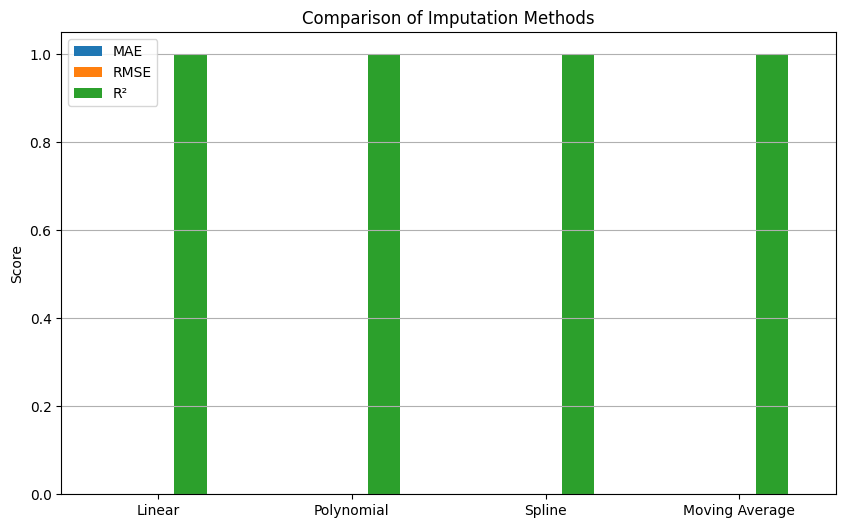

In [13]:
# ===== 6. วาดกราฟเปรียบเทียบ =====
results_df.plot(kind='bar', figsize=(10,6))
plt.title('Comparison of Imputation Methods')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

Model

In [14]:
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [15]:
# โหลดข้อมูลจาก Excel
df = pd.read_excel("/content/data_polynomial_interpolated.xlsx")

In [22]:
X = df.drop('PWAT', axis=1)
y = df['PWAT']

# แปลง non-numeric ให้เป็น NaN
X = X.apply(pd.to_numeric, errors='coerce')

# ===== Polynomial Interpolation =====
X_imputed = X.interpolate(method='polynomial', order=2)

               Date  Showalter    Lifted     SWEAT         K     Cross  \
Date       1.000000  -0.088157 -0.135289 -0.030743  0.097494  0.083550   
Showalter -0.088157   1.000000  0.821015 -0.732903 -0.828853 -0.978044   
Lifted    -0.135289   0.821015  1.000000 -0.469061 -0.573061 -0.833690   
SWEAT     -0.030743  -0.732903 -0.469061  1.000000  0.638863  0.757807   
K          0.097494  -0.828853 -0.573061  0.638863  1.000000  0.790295   
Cross      0.083550  -0.978044 -0.833690  0.757807  0.790295  1.000000   
Vertical   0.016074  -0.296295 -0.070649 -0.032494  0.283367  0.118273   
TT Totals  0.080206  -0.978048 -0.767834  0.662931  0.806210  0.933146   
CAPE       0.143396  -0.633822 -0.817488  0.420408  0.402925  0.684957   
CIN       -0.004249  -0.286193  0.211136  0.338897  0.594400  0.224777   
BRN       -0.074903  -0.300620 -0.332917  0.264279  0.245162  0.299822   
LCL Temp   0.109142  -0.664804 -0.932606  0.416159  0.429026  0.723798   
LCL P      0.074447  -0.533643 -0.8240

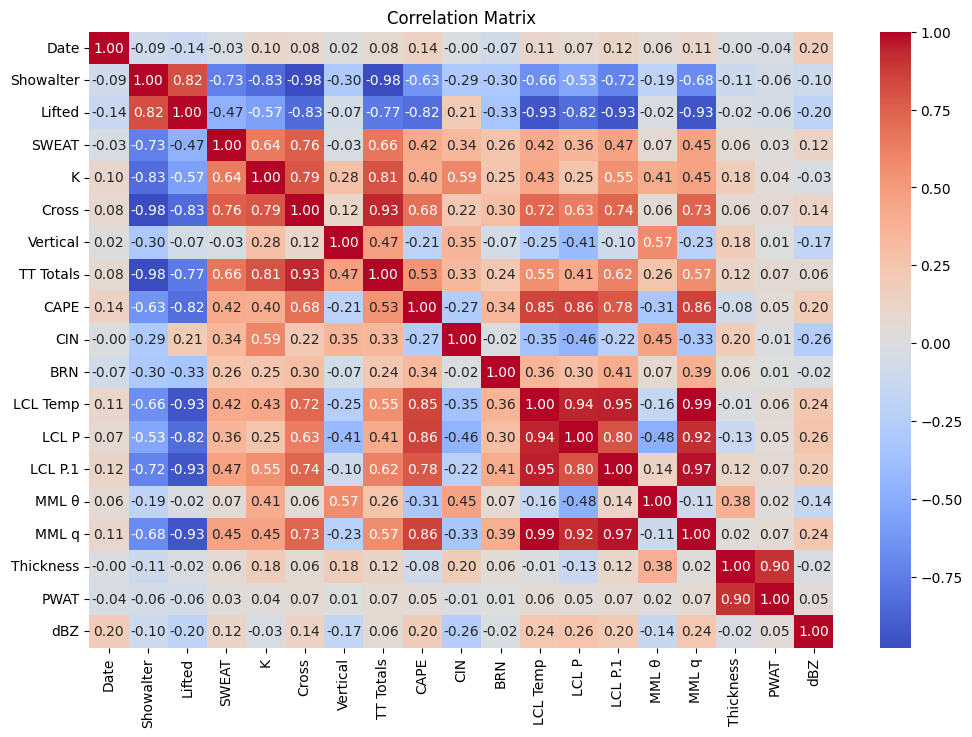

In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# ตรวจสอบความสัมพันธ์เชิงตัวเลข (Correlation)
correlation_matrix = df.corr()
print(correlation_matrix)

# วาด Heatmap แสดงความสัมพันธ์
plt.figure(figsize=(12,8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [28]:
# ------------------- เลือกตัวแปรที่สัมพันธ์กับ y -------------------
target = 'PWAT'   # กำหนด target ที่สนใจ
corr_with_y = correlation_matrix[target].sort_values(ascending=False)

print("Correlation with target (PWAT):")
print(corr_with_y)

# ------------------- เลือกตัวแปรที่มีค่า correlation เกิน threshold -------------------
threshold = 0.9  # กำหนดเกณฑ์ (เช่น |corr| >= 0.9)
selected_features = corr_with_y[abs(corr_with_y) >= threshold].index.tolist()

# ลบ target ออกจาก list
selected_features = [f for f in selected_features if f != target]

print("\nSelected Features (|corr| >= 0.9):")
print(selected_features)

Correlation with target (PWAT):
PWAT         1.000000
Thickness    0.901804
LCL P.1      0.070412
Cross        0.069036
TT Totals    0.065254
MML q        0.065054
LCL Temp     0.061055
CAPE         0.048520
dBZ          0.047902
LCL P        0.046852
K            0.040424
SWEAT        0.029978
MML θ        0.023040
Vertical     0.010467
BRN          0.006992
CIN         -0.008150
Date        -0.035358
Showalter   -0.059800
Lifted      -0.060957
Name: PWAT, dtype: float64

Selected Features (|corr| >= 0.9):
['Thickness']


In [29]:
# ------------------- แบ่งข้อมูล -------------------
X_train, X_test, y_train, y_test = train_test_split(X_imputed, y, test_size=0.2, random_state=42)

In [30]:
# ------------------- สเกลข้อมูล -------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [31]:
# ------------------- ฟังก์ชันประเมินผล -------------------
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred) # Calculate MSE
    rmse = np.sqrt(mse) # Calculate RMSE manually
    r2 = r2_score(y_test, y_pred)
    print(f"{name:<20} | MAE: {mae:.2f} | RMSE: {rmse:.2f} | R²: {r2:.2f}")
    return mae, rmse, r2

In [32]:
# ------------------- สร้างและประเมินโมเดล -------------------
print("Model Comparison (after Polynomial Interpolation):")
print("-" * 65)

Model Comparison (after Polynomial Interpolation):
-----------------------------------------------------------------


In [33]:
# Impute missing values in y_train and y_test
from sklearn.impute import SimpleImputer
imputer_y = SimpleImputer(strategy='mean')
y_train_imputed = imputer_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()
y_test_imputed = imputer_y.transform(y_test.values.reshape(-1, 1)).ravel()

# Linear Regression
lr = LinearRegression()
evaluate_model("Linear Regression", lr, X_train_scaled, X_test_scaled, y_train_imputed, y_test_imputed)

Linear Regression    | MAE: 45.02 | RMSE: 60.67 | R²: -12.50


(45.0206877966592, np.float64(60.670612439280234), -12.5015298983842)

In [34]:
# Impute missing values in y_train and y_test for Random Forest
from sklearn.impute import SimpleImputer
imputer_y = SimpleImputer(strategy='mean')
y_train_imputed_rf = imputer_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()
y_test_imputed_rf = imputer_y.transform(y_test.values.reshape(-1, 1)).ravel()

# Random Forest
rf = RandomForestRegressor(random_state=42)
evaluate_model("Random Forest", rf, X_train_scaled, X_test_scaled, y_train_imputed_rf, y_test_imputed_rf)

Random Forest        | MAE: 3.11 | RMSE: 4.11 | R²: 0.94


(3.112353135764745, np.float64(4.106464381184881), 0.9381467755046436)

In [35]:
# Impute missing values in y_train and y_test for XGBoost
from sklearn.impute import SimpleImputer
imputer_y = SimpleImputer(strategy='mean')
y_train_imputed_xgb = imputer_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()
y_test_imputed_xgb = imputer_y.transform(y_test.values.reshape(-1, 1)).ravel()

# XGBoost
xgb = XGBRegressor(random_state=42, verbosity=0)
evaluate_model("XGBoost", xgb, X_train_scaled, X_test_scaled, y_train_imputed_xgb, y_test_imputed_xgb)

XGBoost              | MAE: 26.81 | RMSE: 209.92 | R²: -160.63


(26.8124708798314, np.float64(209.91537823734518), -160.6273067606862)

Linear Regression    | MAE: 45.02 | RMSE: 60.67 | R²: -12.50
Random Forest        | MAE: 3.11 | RMSE: 4.11 | R²: 0.94
XGBoost              | MAE: 26.81 | RMSE: 209.92 | R²: -160.63


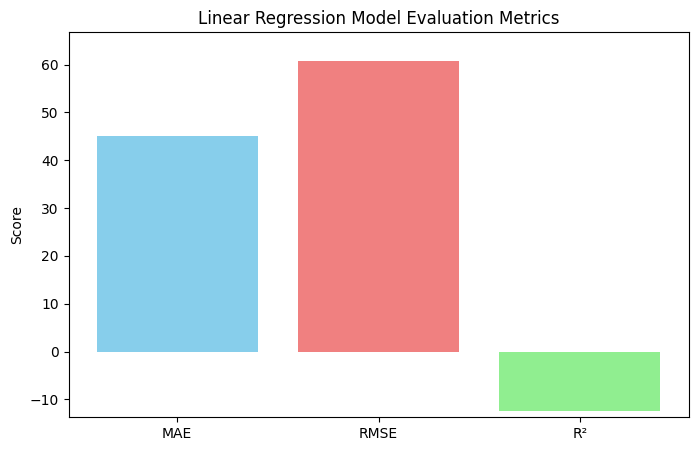

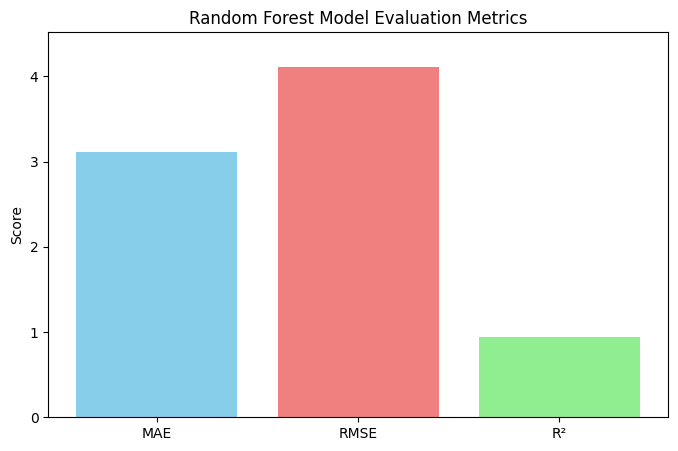

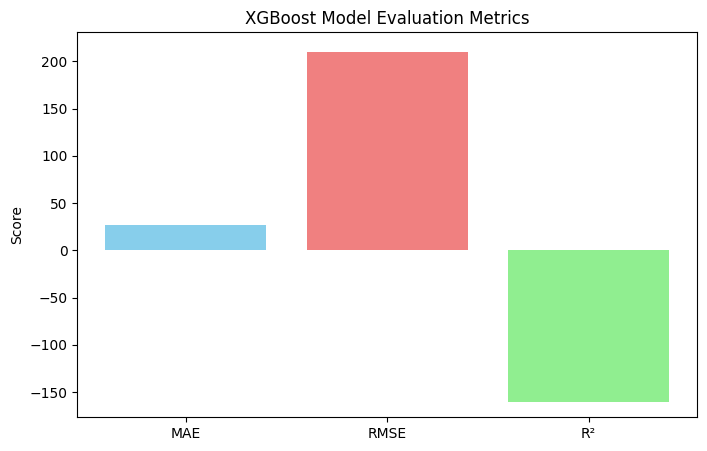

In [36]:
# Get the evaluation metrics for each model
mae_lr, rmse_lr, r2_lr = evaluate_model("Linear Regression", lr, X_train_scaled, X_test_scaled, y_train_imputed, y_test_imputed)
mae_rf, rmse_rf, r2_rf = evaluate_model("Random Forest", rf, X_train_scaled, X_test_scaled, y_train_imputed_rf, y_test_imputed_rf)
mae_xgb, rmse_xgb, r2_xgb = evaluate_model("XGBoost", xgb, X_train_scaled, X_test_scaled, y_train_imputed_xgb, y_test_imputed_xgb)

# Create lists for metrics and their values for each model
metrics = ['MAE', 'RMSE', 'R²']
values_lr = [mae_lr, rmse_lr, r2_lr]
values_rf = [mae_rf, rmse_rf, r2_rf]
values_xgb = [mae_xgb, rmse_xgb, r2_xgb]

# Create bar chart for Linear Regression
plt.figure(figsize=(8, 5))
plt.bar(metrics, values_lr, color=['skyblue', 'lightcoral', 'lightgreen'])
plt.ylabel('Score')
plt.title('Linear Regression Model Evaluation Metrics')
plt.ylim(min(0, min(values_lr) * 1.1), max(values_lr) * 1.1)
plt.show()

# Create bar chart for Random Forest
plt.figure(figsize=(8, 5))
plt.bar(metrics, values_rf, color=['skyblue', 'lightcoral', 'lightgreen'])
plt.ylabel('Score')
plt.title('Random Forest Model Evaluation Metrics')
plt.ylim(min(0, min(values_rf) * 1.1), max(values_rf) * 1.1)
plt.show()

# Create bar chart for XGBoost
plt.figure(figsize=(8, 5))
plt.bar(metrics, values_xgb, color=['skyblue', 'lightcoral', 'lightgreen'])
plt.ylabel('Score')
plt.title('XGBoost Model Evaluation Metrics')
plt.ylim(min(0, min(values_xgb) * 1.1), max(values_xgb) * 1.1)
plt.show()

In [39]:
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
import matplotlib.pyplot as plt

# ===== ฟังก์ชันตรวจ Overfitting =====
def check_overfitting(name, model, X_train, X_test, y_train, y_test):
    mae_train, rmse_train, r2_train = evaluate_model(f"{name} (Train)", model, X_train, X_train, y_train, y_train)
    mae_test, rmse_test, r2_test = evaluate_model(f"{name} (Test)", model, X_train, X_test, y_train, y_test)

    print(f"\n--- Overfitting Check ({name}) ---")
    print(f"Train: MAE={mae_train:.4f}, RMSE={rmse_train:.4f}, R²={r2_train:.4f}")
    print(f"Test : MAE={mae_test:.4f}, RMSE={rmse_test:.4f}, R²={r2_test:.4f}")

    if abs(r2_train - r2_test) > 0.15 and r2_train > r2_test:
        print(f" อาจมี Overfitting ใน {name}")
    else:
        print(f" {name} ไม่มี Overfitting รุนแรง")

# ===== 1. Linear Regression =====
print("\n===== Linear Regression =====")
imputer_y_lr = SimpleImputer(strategy='mean')
y_train_lr = imputer_y_lr.fit_transform(y_train.values.reshape(-1, 1)).ravel()
y_test_lr = imputer_y_lr.transform(y_test.values.reshape(-1, 1)).ravel()

lr = LinearRegression()
evaluate_model("Linear Regression", lr, X_train_scaled, X_test_scaled, y_train_lr, y_test_lr)
check_overfitting("Linear Regression", lr, X_train_scaled, X_test_scaled, y_train_lr, y_test_lr)

# ===== 2. Random Forest =====
print("\n===== Random Forest =====")
imputer_y_rf = SimpleImputer(strategy='mean')
y_train_rf = imputer_y_rf.fit_transform(y_train.values.reshape(-1, 1)).ravel()
y_test_rf = imputer_y_rf.transform(y_test.values.reshape(-1, 1)).ravel()

rf = RandomForestRegressor(random_state=42)
evaluate_model("Random Forest", rf, X_train_scaled, X_test_scaled, y_train_rf, y_test_rf)
check_overfitting("Random Forest", rf, X_train_scaled, X_test_scaled, y_train_rf, y_test_rf)

# ===== 3. XGBoost =====
print("\n===== XGBoost =====")
imputer_y_xgb = SimpleImputer(strategy='mean')
y_train_xgb = imputer_y_xgb.fit_transform(y_train.values.reshape(-1, 1)).ravel()
y_test_xgb = imputer_y_xgb.transform(y_test.values.reshape(-1, 1)).ravel()

xgb = XGBRegressor(random_state=42)
evaluate_model("XGBoost", xgb, X_train_scaled, X_test_scaled, y_train_xgb, y_test_xgb)
check_overfitting("XGBoost", xgb, X_train_scaled, X_test_scaled, y_train_xgb, y_test_xgb)



===== Linear Regression =====
Linear Regression    | MAE: 45.02 | RMSE: 60.67 | R²: -12.50
Linear Regression (Train) | MAE: 39.45 | RMSE: 54.94 | R²: 0.98
Linear Regression (Test) | MAE: 45.02 | RMSE: 60.67 | R²: -12.50

--- Overfitting Check (Linear Regression) ---
Train: MAE=39.4510, RMSE=54.9394, R²=0.9842
Test : MAE=45.0207, RMSE=60.6706, R²=-12.5015
 อาจมี Overfitting ใน Linear Regression

===== Random Forest =====
Random Forest        | MAE: 3.11 | RMSE: 4.11 | R²: 0.94
Random Forest (Train) | MAE: 14.74 | RMSE: 199.48 | R²: 0.79
Random Forest (Test) | MAE: 3.11 | RMSE: 4.11 | R²: 0.94

--- Overfitting Check (Random Forest) ---
Train: MAE=14.7400, RMSE=199.4771, R²=0.7918
Test : MAE=3.1124, RMSE=4.1065, R²=0.9381
 Random Forest ไม่มี Overfitting รุนแรง

===== XGBoost =====
XGBoost              | MAE: 26.81 | RMSE: 209.92 | R²: -160.63
XGBoost (Train)      | MAE: 0.01 | RMSE: 0.02 | R²: 1.00
XGBoost (Test)       | MAE: 26.81 | RMSE: 209.92 | R²: -160.63

--- Overfitting Check (XG

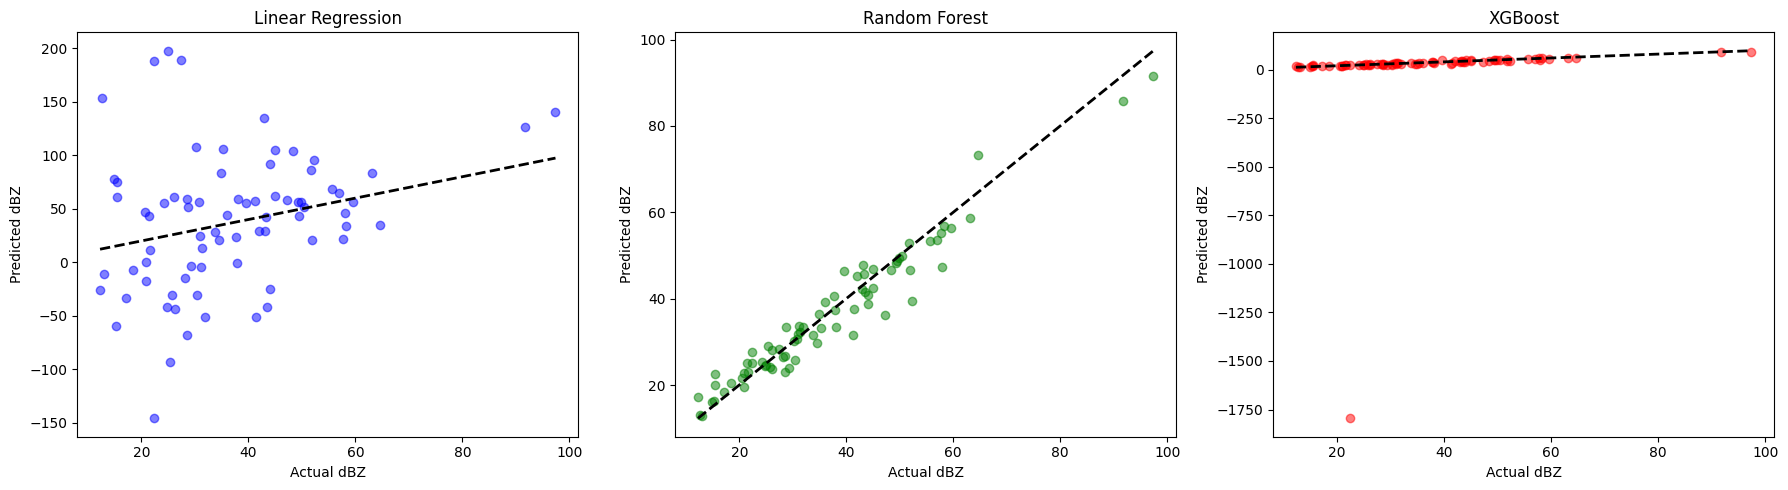

In [38]:
import matplotlib.pyplot as plt

# ===== 1. Linear Regression =====
y_pred_lr = lr.predict(X_test_scaled)

# ===== 2. Random Forest =====
y_pred_rf = rf.predict(X_test_scaled)

# ===== 3. XGBoost =====
y_pred_xgb = xgb.predict(X_test_scaled)

# ===== Visualization =====
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Linear Regression ---
axes[0].scatter(y_test, y_pred_lr, alpha=0.5, color="blue")
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
axes[0].set_title("Linear Regression")
axes[0].set_xlabel("Actual dBZ")
axes[0].set_ylabel("Predicted dBZ")

# --- Random Forest ---
axes[1].scatter(y_test, y_pred_rf, alpha=0.5, color="green")
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
axes[1].set_title("Random Forest")
axes[1].set_xlabel("Actual dBZ")
axes[1].set_ylabel("Predicted dBZ")

# --- XGBoost ---
axes[2].scatter(y_test, y_pred_xgb, alpha=0.5, color="red")
axes[2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
axes[2].set_title("XGBoost")
axes[2].set_xlabel("Actual dBZ")
axes[2].set_ylabel("Predicted dBZ")

plt.tight_layout()
plt.show()
